In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/test/ECG Images of Patient that have abnormal heartbeat (233x12=2796)/HB(187).jpg
/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/test/ECG Images of Patient that have abnormal heartbeat (233x12=2796)/HB(73).jpg
/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/test/ECG Images of Patient that have abnormal heartbeat (233x12=2796)/HB(158).jpg
/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/test/ECG Images of Patient that have abnormal heartbeat (233x12=2796)/HB(69).jpg
/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/test/ECG Images of Patient that have abnormal heartbeat (233x12=2796)/HB(66).jpg
/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/test/ECG Images of Patient that have abnormal heartbeat (233x12=2796)/HB(92).jpg
/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/test/ECG Images of Patient that have abnormal heartbeat (233x12=2796)/HB(231).

In [2]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [3]:
print(os.listdir('/kaggle/input/datasets'))

['kanishkarathore1604']


In [4]:
print(os.listdir('/kaggle/input/datasets/kanishkarathore1604'))

['ecg-image']


In [5]:
base_dir = '/kaggle/input/datasets/kanishkarathore1604/ecg-image'
print(os.listdir(base_dir))


['ECG_DATA']


In [6]:
base_dir = '/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA'
print(os.listdir(base_dir))

['test', 'train']


In [7]:
base_dir = '/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA'

In [8]:
print(os.listdir(base_dir + '/train'))

['ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'Normal Person ECG Images (284x12=3408)', 'ECG Images of Myocardial Infarction Patients (240x12=2880)']


In [9]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
train_dir = base_dir + '/train'
test_dir = base_dir + '/test'

img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 2420 images belonging to 4 classes.
Found 603 images belonging to 4 classes.


In [11]:
print("Training images:", train_gen.samples)
print("Validation images:", val_gen.samples)

Training images: 2420
Validation images: 603


In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False

I0000 00:00:1789932343.750726      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789932343.753688      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [14]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [16]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10


2026-09-20 19:26:03.297477: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 19:26:03.434065: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789932365.204050     152 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/76 ━━━━━━━━━━━━━━━━━━━━ 6s 769ms/step - accuracy: 0.4740 - loss: 1.2318

2026-09-20 19:27:05.718762: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 19:27:05.867601: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 19:27:06.003730: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.4841 - loss: 1.2114

2026-09-20 19:27:39.934659: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 19:27:40.071176: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


76/76 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5756 - loss: 1.0301 - val_accuracy: 0.6600 - val_loss: 0.8637
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 54s 717ms/step - accuracy: 0.7128 - loss: 0.7508 - val_accuracy: 0.7197 - val_loss: 0.7414
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 54s 709ms/step - accuracy: 0.7496 - loss: 0.6534 - val_accuracy: 0.7065 - val_loss: 0.7117
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 55s 721ms/step - accuracy: 0.7946 - loss: 0.5637 - val_accuracy: 0.8010 - val_loss: 0.5308
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 56s 738ms/step - accuracy: 0.8174 - loss: 0.4956 - val_accuracy: 0.8209 - val_loss: 0.5050
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 56s 736ms/step - accuracy: 0.8318 - loss: 0.4665 - val_accuracy: 0.8109 - val_loss: 0.4978
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 54s 715ms/step - accuracy: 0.8388 - loss: 0.4219 - val_accuracy: 0.8607 - val_loss: 0.4472
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 56s 737ms/step - accuracy: 0.8612 - loss: 0.3761 - val_accuracy: 0.8259 

In [17]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen=test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
    
)
test_loss,test_acc= model.evaluate(test_gen)
print("Test Accuracy:",test_acc)


Found 928 images belonging to 4 classes.
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 751ms/step - accuracy: 0.9030 - loss: 0.2927
Test Accuracy: 0.9030172228813171


In [19]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 592ms/step
                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.94      1.00      0.97       239
     ECG Images of Patient that have History of MI (172x12=2064)       0.80      0.77      0.79       172
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.96      0.86      0.91       233
                          Normal Person ECG Images (284x12=3408)       0.88      0.94      0.91       284

                                                        accuracy                           0.90       928
                                                       macro avg       0.90      0.89      0.89       928
                                                    weighted avg       0.90      0.90      0.90       928



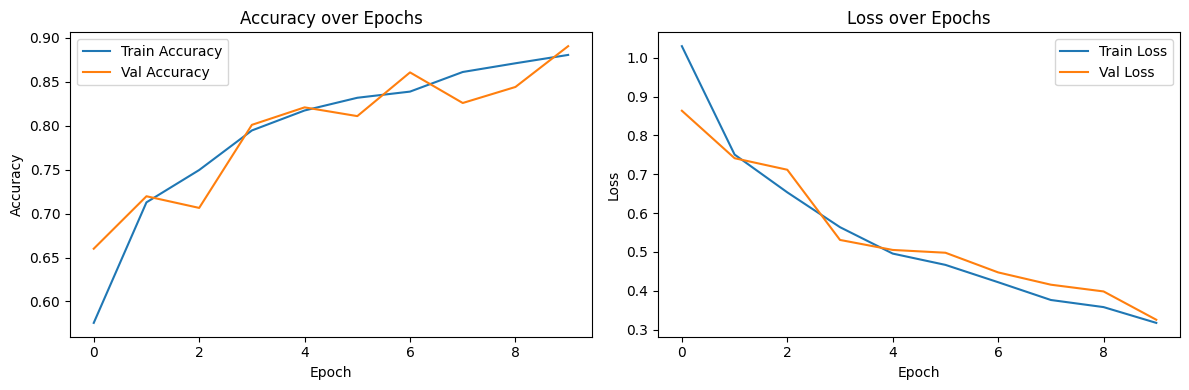

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

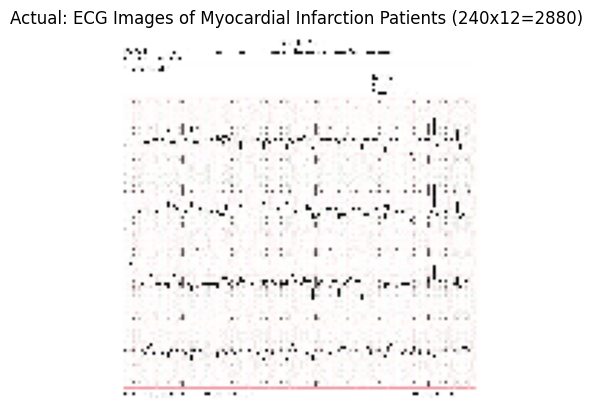

In [25]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# Ek sample image path lo test set se
sample_path = test_gen.filepaths[0]
sample_label = class_names[test_gen.classes[0]]

img = image.load_img(sample_path, target_size=img_size)
img_array = image.img_to_array(img) / 255.0
img_array_batch = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.title(f"Actual: {sample_label}")
plt.axis('off')2222
plt.show()

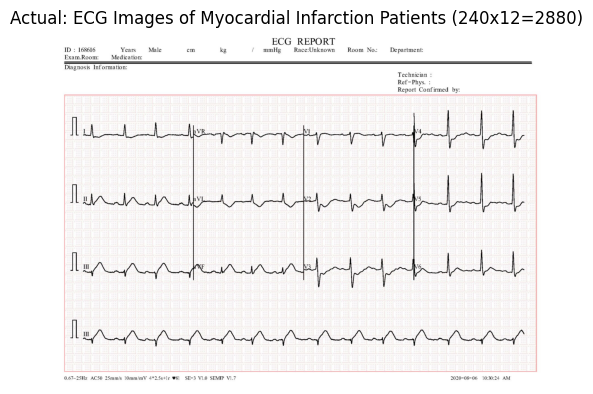

In [24]:
img_original = image.load_img(sample_path)  # no target_size = original resolution

plt.imshow(img_original)
plt.title(f"Actual: {sample_label}")
plt.axis('off')
plt.show()

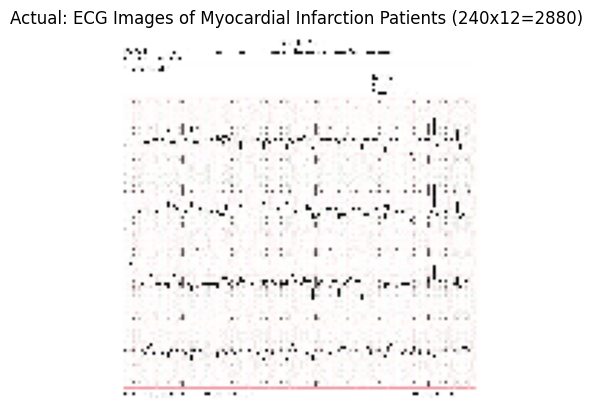

In [27]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# Ek sample image path lo test set se
sample_path = test_gen.filepaths[0]
sample_label = class_names[test_gen.classes[0]]

img = image.load_img(sample_path, target_size=img_size)
img_array = image.img_to_array(img) / 255.0
img_array_batch = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.title(f"Actual: {sample_label}")
plt.axis('off')
plt.show()

In [29]:
import tensorflow as tf

def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy(), pred_index.numpy()

In [30]:
for layer in model.layers[-10:]:
    print(layer.name)

block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu
global_average_pooling2d
dense
dense_1


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


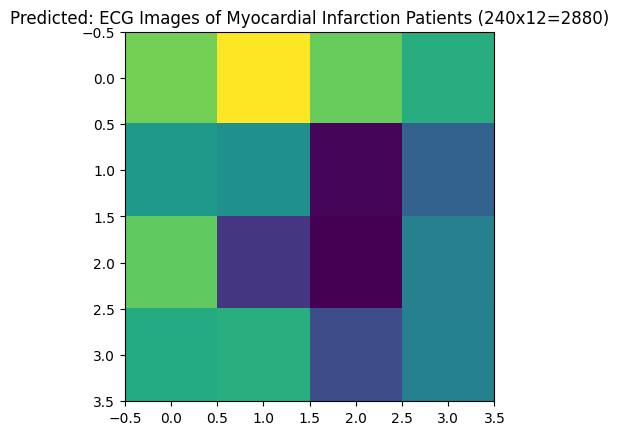

In [31]:
heatmap, pred_class_idx = get_gradcam_heatmap(img_array_batch, model, 'Conv_1')

plt.imshow(heatmap)
plt.title(f"Predicted: {class_names[pred_class_idx]}")
plt.show()

In [38]:
model.save('ecg_model.h5')

In [39]:
model.save('ecg_model.keras')

In [40]:
!pip install gradio -q

In [41]:
import gradio as gr
from PIL import Image

def predict_ecg(img):
    img = img.resize(img_size)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    preds = model.predict(img_array)[0]
    result = {class_names[i]: float(preds[i]) for i in range(len(class_names))}
    return result

demo = gr.Interface(
    fn=predict_ecg,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=4),
    title="ECG Image Classifier",
    description="Upload an ECG image to classify: Normal, MI, History of MI, or Abnormal Heartbeat"
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://b7cb84f632a682d3b7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [42]:
import shutil
shutil.copy(sample_path, '/kaggle/working/sample_ecg.jpg')
print("Saved:", sample_path)

Saved: /kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/test/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(1).jpg
